In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv("mpg_raw.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 35.9 KB


In [5]:
df.shape

(398, 9)

In [6]:
df.describe() #only shows numerical values 

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [8]:
df.describe(exclude="number") #excluse numrical values
#if we want describtion of all tybes of data:   df.describe(include="all")

,origin,name
count,398,398
unique,3,305
top,usa,ford pinto
freq,249,6


In [9]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Text(0.5, 1.0, 'MPG Distribution')

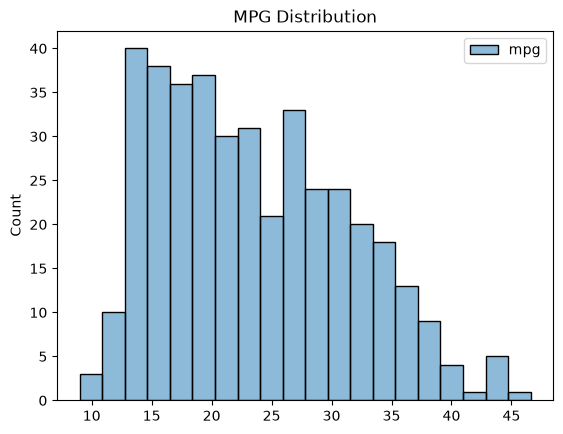

In [12]:
sns.histplot([df.mpg], bins=20)
plt.title('MPG Distribution')

Text(0.5, 1.0, 'MPG Distribution')

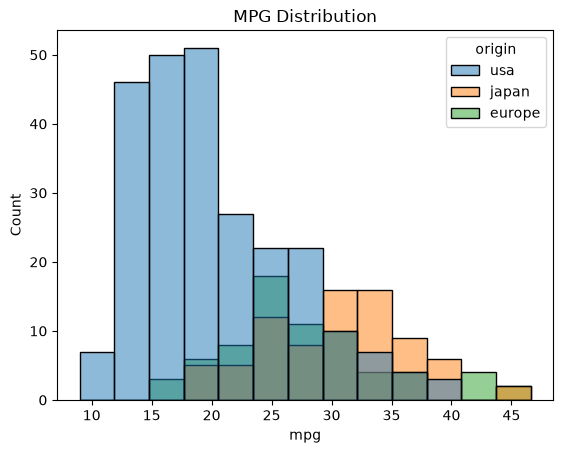

In [13]:
sns.histplot(df, x="mpg", hue="origin")
plt.title('MPG Distribution')

Text(0.5, 1.0, 'MPG Distribution')

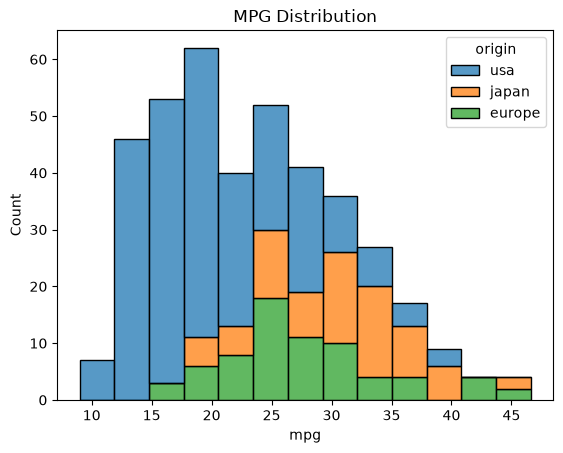

In [14]:
sns.histplot(df, x="mpg", hue="origin", multiple="stack")
plt.title('MPG Distribution')

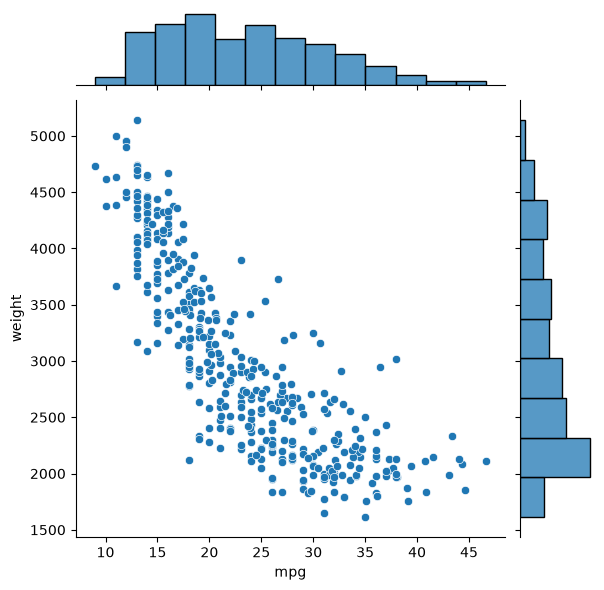

In [15]:
sns.jointplot(x='mpg', y='weight', data=df, kind='scatter')

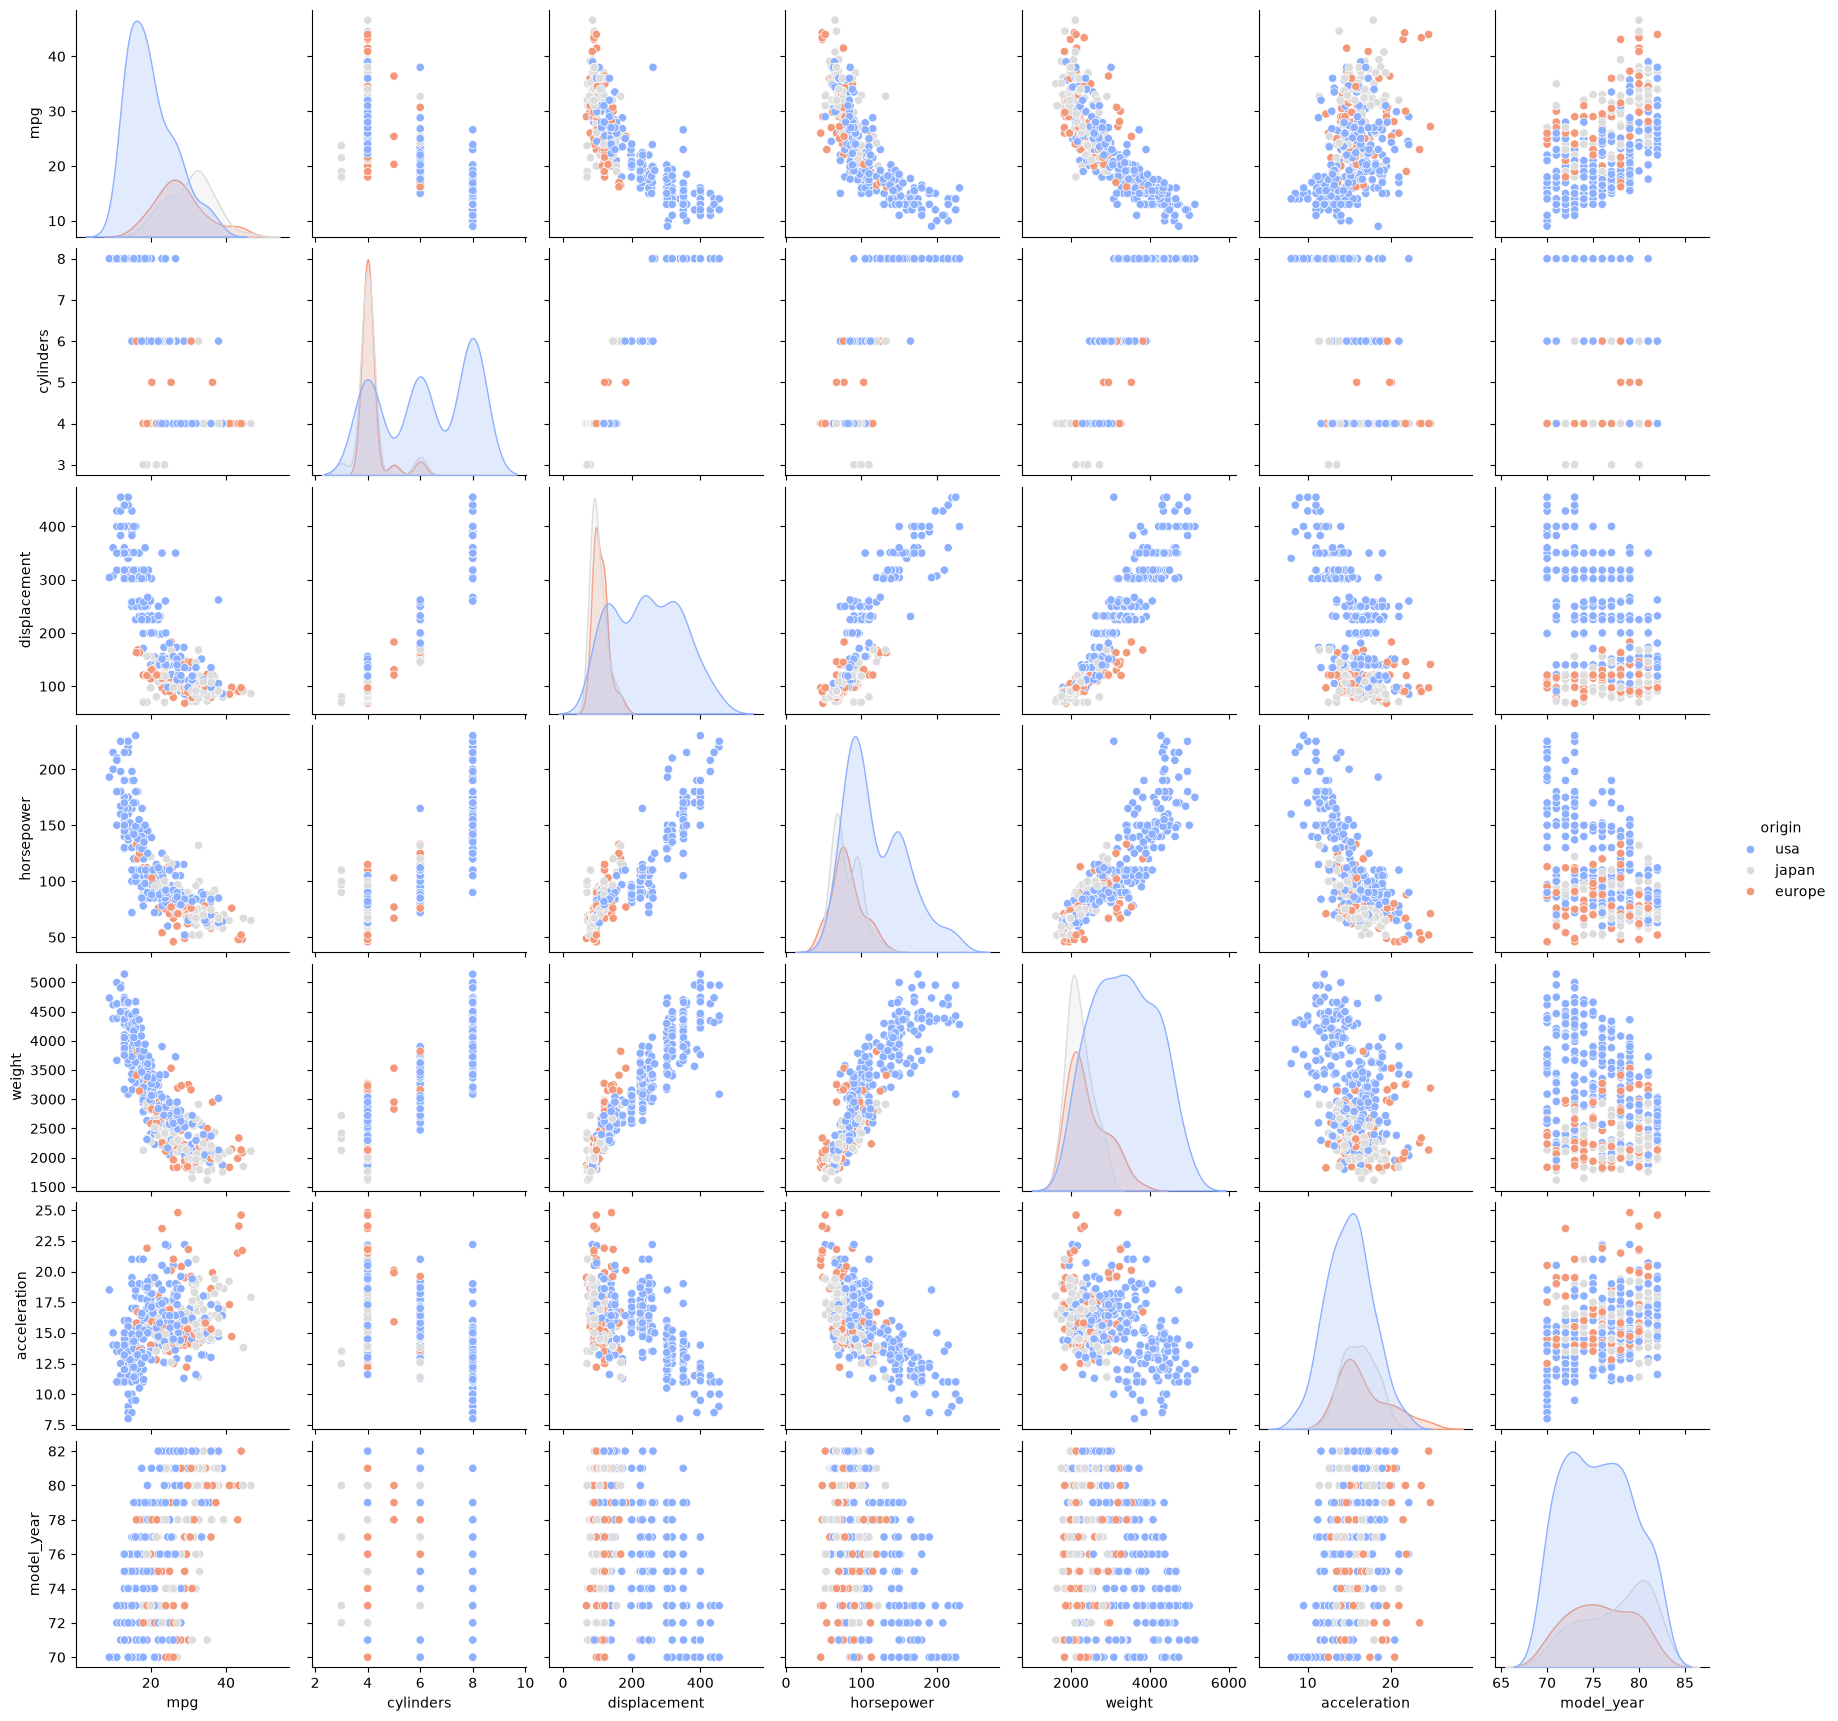

In [19]:
#very important function we use it before bulding a machine learning model to get info about relationship and best model
sns.pairplot(df, hue="origin", palette= 'coolwarm')
# hue is how the figue will be colored based on countries distributions & coolwarm is the pallete 

Text(0.5, 1.0, 'KDE Chart')

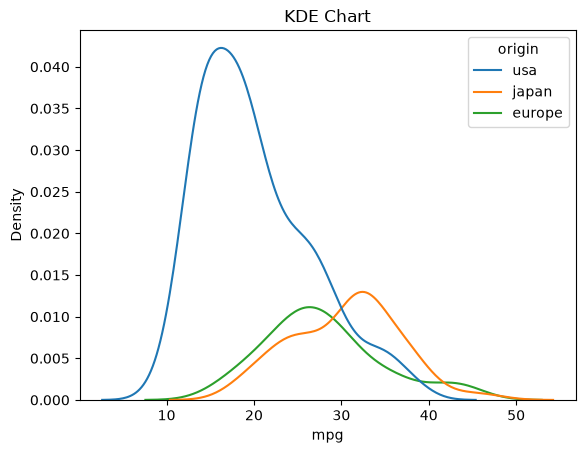

In [24]:
sns.kdeplot(data=df, x='mpg', hue='origin')
plt.title ("KDE Chart")

<Axes: xlabel='origin', ylabel='horsepower'>

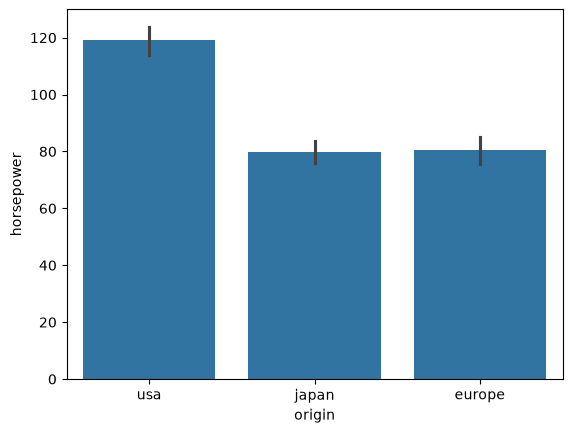

In [25]:
sns.barplot(x='origin', y='horsepower', data=df) #these estimators are built based on mean, to change them ->

<Axes: xlabel='origin', ylabel='horsepower'>

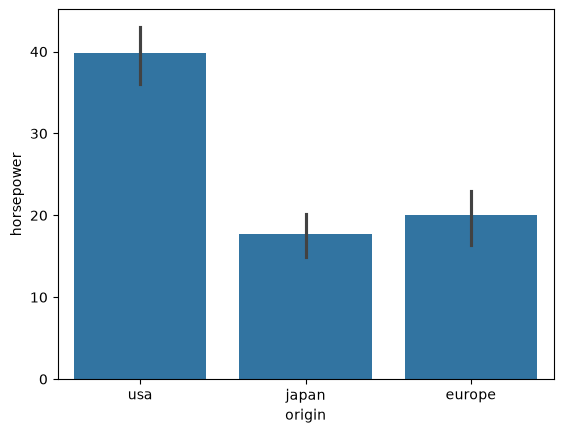

In [26]:
# ->
sns.barplot(x='origin', y='horsepower', data=df, estimator= np.std)#now it is based on standard-divition

<Axes: xlabel='origin', ylabel='count'>

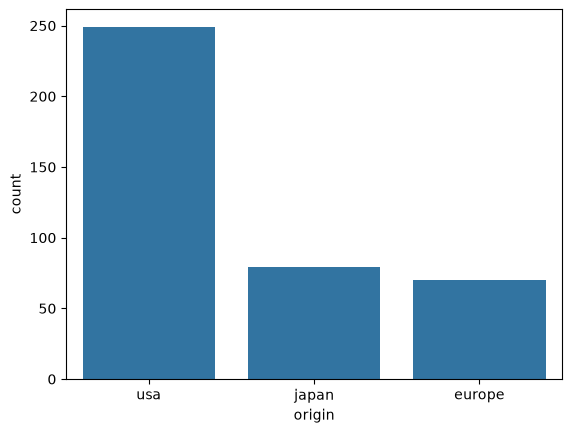

In [27]:
sns.countplot(x='origin',data=df)

In [29]:
#using countplot on differnt charts 
#1- starting with analysis
df['mpg_level']= df['mpg'].apply(lambda x: 'Low' if x<15 else 'High' if x>30 else 'Medium')
#اضفت عمود جديد اسمه امبيجي ليفل وهذا العمود يطبق فنكشن تحسب كل متغير اكس اذا كان اقل من ١٥ فهو لو ، اكبر من ٣٠ هاي ، شي ثاني ميديوم
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,mpg_level
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,Medium
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,Medium
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,Medium
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,Medium
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,Medium


<Figure size 1500x800 with 0 Axes>

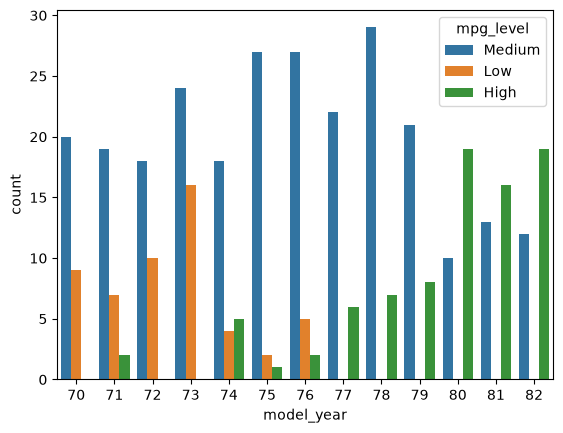

<Figure size 1500x800 with 0 Axes>

In [31]:
sns.countplot(x="model_year", hue= 'mpg_level', data=df)
plt.figure(figsize=(15,8))

<Figure size 2500x1500 with 0 Axes>

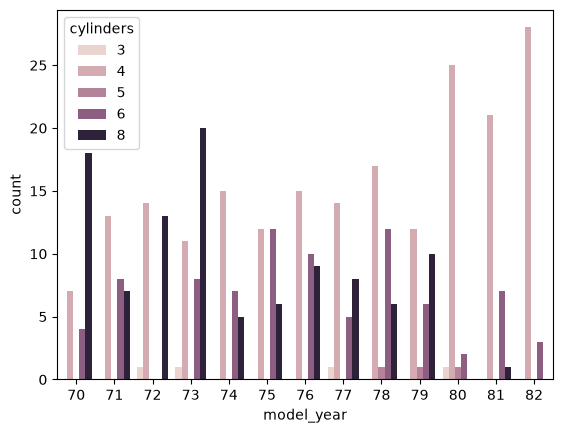

<Figure size 2500x1500 with 0 Axes>

In [35]:
sns.countplot(x="model_year", hue= 'cylinders', data=df)
plt.figure(figsize=(25,15))

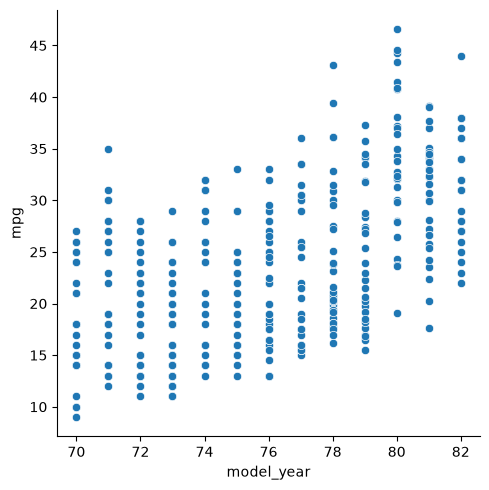

In [39]:
sns.relplot(x="model_year", y='mpg', data=df);

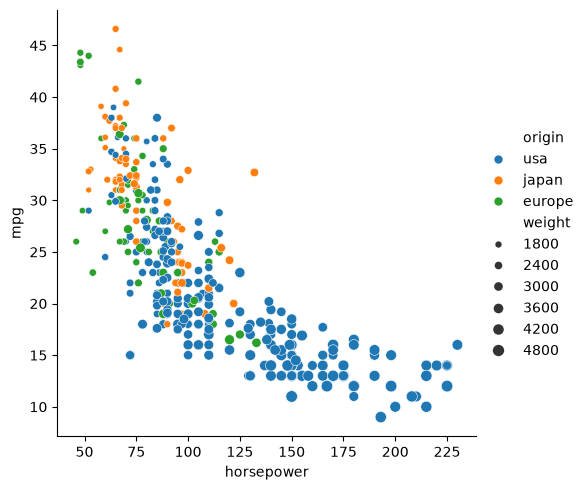

In [42]:
sns.relplot(x="horsepower", y='mpg', hue='origin' , size= 'weight' ,data=df);

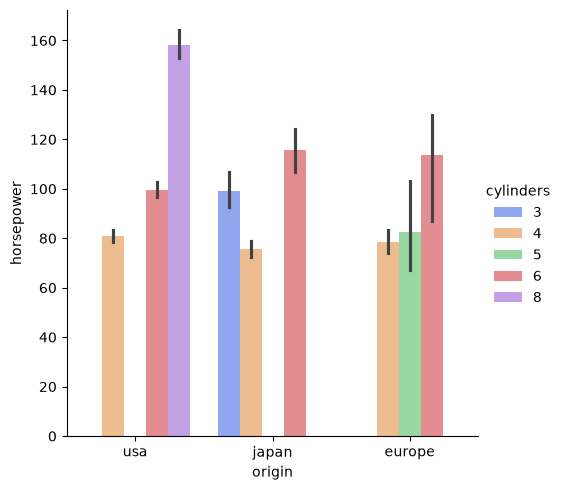

In [49]:
sns.catplot(data=df,kind="bar",x='origin', y='horsepower', hue='cylinders', alpha=0.5, height=5, palette="bright");

<Axes: xlabel='origin', ylabel='mpg'>

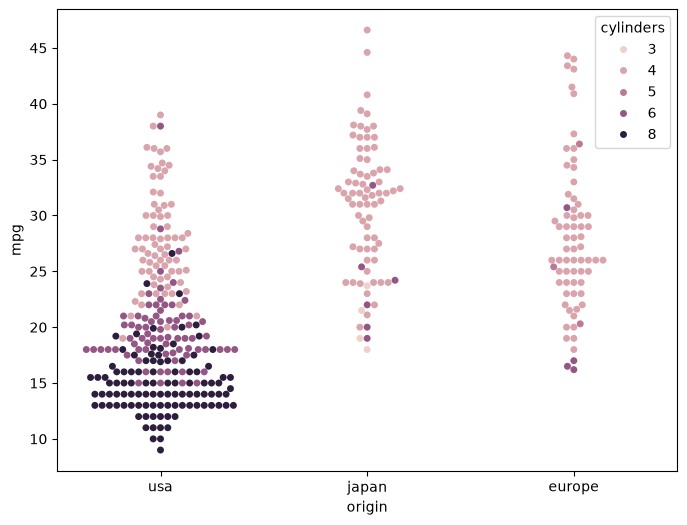

In [54]:
plt.figure(figsize=(8,6))
sns.swarmplot (x='origin', y='mpg', hue='cylinders', data=df)

In [60]:
df[(df['origin']=='japan') & (df['cylinders']== 6) & (df['mpg']>30)]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,mpg_level
333,32.7,6,168.0,132.0,2910,11.4,80,japan,datsun 280-zx,High


In [61]:
df[(df['origin']=='usa') & (df['cylinders']== 6) & (df['mpg']>35)]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,mpg_level
387,38.0,6,262.0,85.0,3015,17.0,82,usa,oldsmobile cutlass ciera (diesel),High


In [62]:
df[(df['origin']=='usa') & (df['cylinders']== 8) & (df['mpg']>25)]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,mpg_level
364,26.6,8,350.0,105.0,3725,19.0,81,usa,oldsmobile cutlass ls,Medium


In [64]:
df[(df['origin']=='japan') & (df['cylinders']== 3) & (df['mpg']<20)]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,mpg_level
71,19.0,3,70.0,97.0,2330,13.5,72,japan,mazda rx2 coupe,Medium
111,18.0,3,70.0,90.0,2124,13.5,73,japan,maxda rx3,Medium


<Axes: ylabel='mpg'>

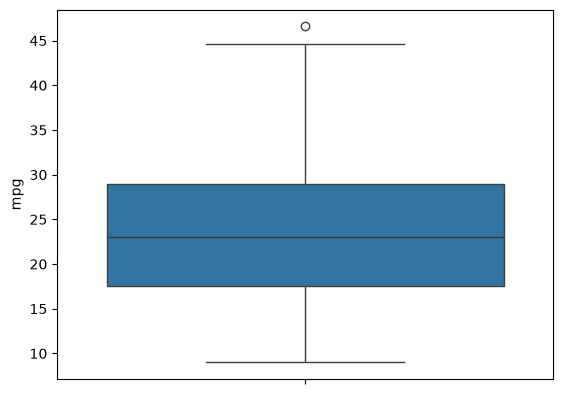

In [66]:
sns.boxplot(data=df['mpg'])

In [67]:
df['mpg'].describe()

count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

<Axes: xlabel='origin', ylabel='mpg'>

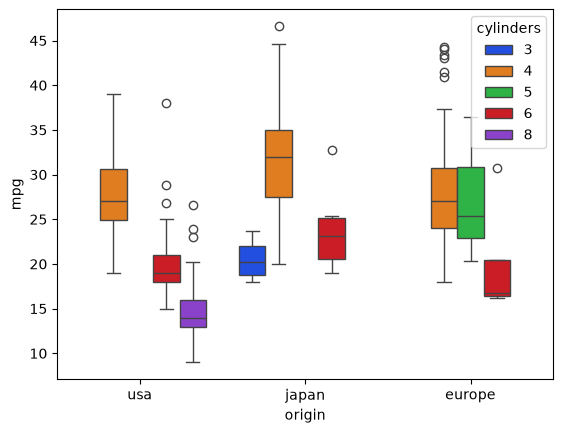

In [72]:
sns.boxplot(x= 'origin',y='mpg',hue='cylinders',data=df, palette='bright')

<Axes: ylabel='mpg'>

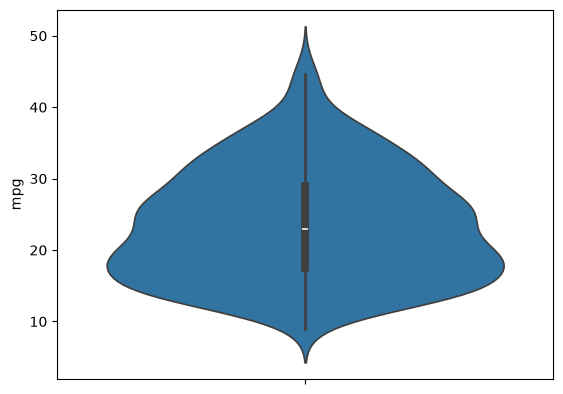

In [73]:
sns.violinplot(data=df['mpg'])

<Axes: xlabel='origin', ylabel='mpg'>

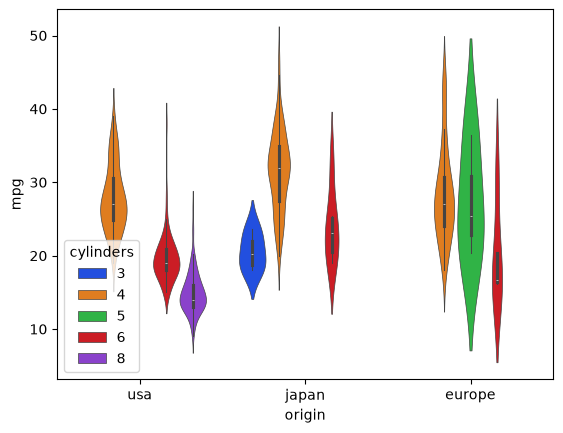

In [76]:
sns.violinplot(x= 'origin',y='mpg',hue='cylinders',data=df, palette='bright',linewidth=0.5)